In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:

data= pd.read_csv('Insurance_claims.csv')

In [3]:
data.head()

,case_id,activity_name,timestamp,claimant_name,agent_name,adjuster_name,claim_amount,claimant_age,type_of_policy,car_make,car_model,car_year,type_of_accident,user_type
0,a626bc58-a7b2-4eff-aca9-2a622cd0c492,First Notification of Loss (FNOL),2020-09-24 14:08:42.423530,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA
1,a626bc58-a7b2-4eff-aca9-2a622cd0c492,Assign Claim,2020-10-13 03:51:28.627923,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA
2,a626bc58-a7b2-4eff-aca9-2a622cd0c492,Claim Decision,2020-10-14 22:30:14.948970,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA
3,a626bc58-a7b2-4eff-aca9-2a622cd0c492,Set Reserve,2020-10-24 11:49:39.053890,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA
4,a626bc58-a7b2-4eff-aca9-2a622cd0c492,Payment Sent,2020-10-27 05:46:04.378718,Karen Lopez,Thomas Cantu,Ian Garcia,1914.96,75,Collision,Honda,Civic,2012,Rollover,RPA


In [4]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180000 entries, 0 to 179999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   case_id           180000 non-null  object 
 1   activity_name     180000 non-null  object 
 2   timestamp         180000 non-null  object 
 3   claimant_name     180000 non-null  object 
 4   agent_name        180000 non-null  object 
 5   adjuster_name     180000 non-null  object 
 6   claim_amount      180000 non-null  float64
 7   claimant_age      180000 non-null  int64  
 8   type_of_policy    180000 non-null  object 
 9   car_make          180000 non-null  object 
 10  car_model         180000 non-null  object 
 11  car_year          180000 non-null  int64  
 12  type_of_accident  180000 non-null  object 
 13  user_type         180000 non-null  object 
dtypes: float64(1), int64(2), object(11)
memory usage: 19.2+ MB


,claim_amount,claimant_age,car_year
count,180000.000000,180000.000000,180000.000000
mean,5498.598991,51.510233,2016.034367
std,2601.273015,19.691143,3.745014
min,1000.280000,18.000000,2010.000000
25%,3242.482500,34.000000,2013.000000
50%,5498.965000,52.000000,2016.000000
75%,7758.817500,69.000000,2019.000000
max,9999.470000,85.000000,2022.000000


In [5]:
data.isna().sum()

case_id             0
activity_name       0
timestamp           0
claimant_name       0
agent_name          0
adjuster_name       0
claim_amount        0
claimant_age        0
type_of_policy      0
car_make            0
car_model           0
car_year            0
type_of_accident    0
user_type           0
dtype: int64

In [6]:
data=data.drop_duplicates()

In [7]:
data["timestamp"] = pd.to_datetime(data["timestamp"])

In [8]:
data.dtypes

case_id                     object
activity_name               object
timestamp           datetime64[ns]
claimant_name               object
agent_name                  object
adjuster_name               object
claim_amount               float64
claimant_age                 int64
type_of_policy              object
car_make                    object
car_model                   object
car_year                     int64
type_of_accident            object
user_type                   object
dtype: object

In [9]:
# trie des evènements par case_id et timestamp
data = data.sort_values(by=["case_id", "timestamp"])

In [10]:
# nbre de dossiers uniques
data["case_id"].nunique()

30000

In [11]:
# nbre d'évènements par dossier
events_per_case = data.groupby("case_id").size()
events_per_case.describe()

count    30000.0
mean         6.0
std          0.0
min          6.0
25%          6.0
50%          6.0
75%          6.0
max          6.0
dtype: float64

In [12]:
# Nettoyage des Activités 

#Suppression des espaces
data["activity_name"] = data["activity_name"].str.strip()

# Uniformisation du texte 
data["activity_name"] = data["activity_name"].str.title()

# voir les activités existantes
data["activity_name"].unique()

array(['First Notification Of Loss (Fnol)', 'Assign Claim',
       'Claim Decision', 'Set Reserve', 'Payment Sent', 'Close Claim'],
      dtype=object)

In [13]:
# Analyse des variables catégorielles
categorical_columns = ["activity_name","type_of_policy","car_make","type_of_accident","user_type"]
for col in categorical_columns:
    print("\nDistribution of", col)
    print(data[col].value_counts())


Distribution of activity_name
activity_name
First Notification Of Loss (Fnol)    30000
Assign Claim                         30000
Claim Decision                       30000
Set Reserve                          30000
Payment Sent                         30000
Close Claim                          30000
Name: count, dtype: int64

Distribution of type_of_policy
type_of_policy
Collision        60126
Comprehensive    60018
Liability        59856
Name: count, dtype: int64

Distribution of car_make
car_make
Ford         26640
Toyota       26376
Honda        25716
Jeep         25632
Chevrolet    25554
Hyundai      25188
Nissan       24894
Name: count, dtype: int64

Distribution of type_of_accident
type_of_accident
Side-impact    45660
Head-on        44994
Rear-end       44946
Rollover       44400
Name: count, dtype: int64

Distribution of user_type
user_type
Human    116400
RPA       63600
Name: count, dtype: int64


In [14]:
# Analyse des valeurs numériques
numerical_columns = ["claim_amount","claimant_age","car_year"]
data[numerical_columns].describe()

,claim_amount,claimant_age,car_year
count,180000.000000,180000.000000,180000.000000
mean,5498.598991,51.510233,2016.034367
std,2601.273015,19.691143,3.745014
min,1000.280000,18.000000,2010.000000
25%,3242.482500,34.000000,2013.000000
50%,5498.965000,52.000000,2016.000000
75%,7758.817500,69.000000,2019.000000
max,9999.470000,85.000000,2022.000000


In [15]:
# Calcul de la durée des processus
process_durations = data.groupby("case_id")["timestamp"].agg(["min", "max"])

process_durations["duration_days"] = (process_durations["max"] - process_durations["min"]).dt   .total_seconds() / (24 * 3600)
process_durations.describe()

,min,max,duration_days
count,30000,30000,30000.000000
mean,2021-10-09 12:11:08.202444544,2021-11-13 12:33:09.570915584,35.015294
min,2020-04-06 07:50:45.322658,2020-05-03 01:57:58.656872,16.903979
25%,2021-01-07 19:01:05.304800,2021-02-11 10:02:13.098419200,31.973660
50%,2021-10-10 07:07:59.356129024,2021-11-14 16:25:06.602764032,35.026091
75%,2022-07-11 00:49:36.593678848,2022-08-14 19:45:58.349171456,38.035351
max,2023-04-15 13:40:34.644530,2023-05-26 01:49:58.261710,54.124193
std,NaN,NaN,4.478180


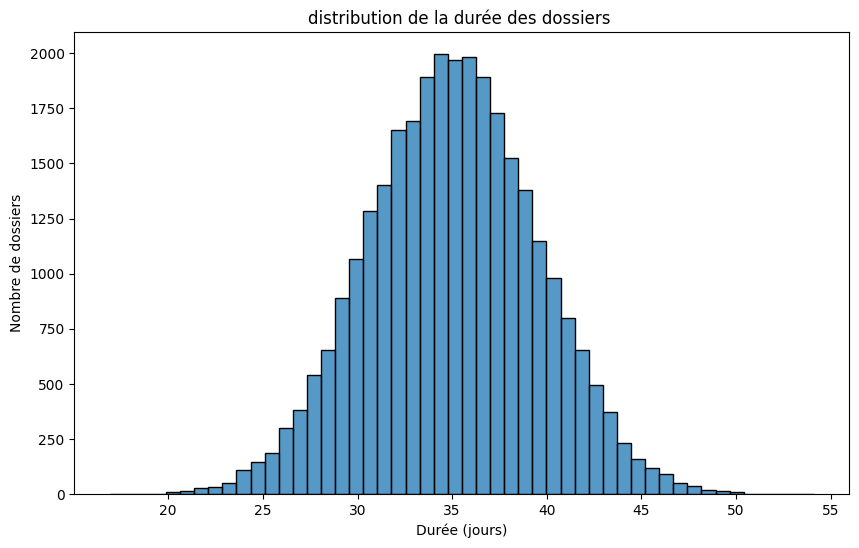

In [16]:
# Visualisation de la durée des dossiers
plt.figure(figsize=(10, 6))
sns.histplot(process_durations["duration_days"], bins=50)
plt.title("distribution de la durée des dossiers ")
plt.xlabel("Durée (jours)")
plt.ylabel("Nombre de dossiers")
plt.show()

In [17]:
# Sauvegarde du dataset nettoyé
data.to_csv("cleaned_insurance_claims.csv", index=False)
print("dataset nettoyé sauvegardé sous 'cleaned_insurance_claims.csv'")

dataset nettoyé sauvegardé sous 'cleaned_insurance_claims.csv'


ANALYSE DU PROCESSUS METIER

In [19]:
activities = data["activity_name"].value_counts()
print

<function print>

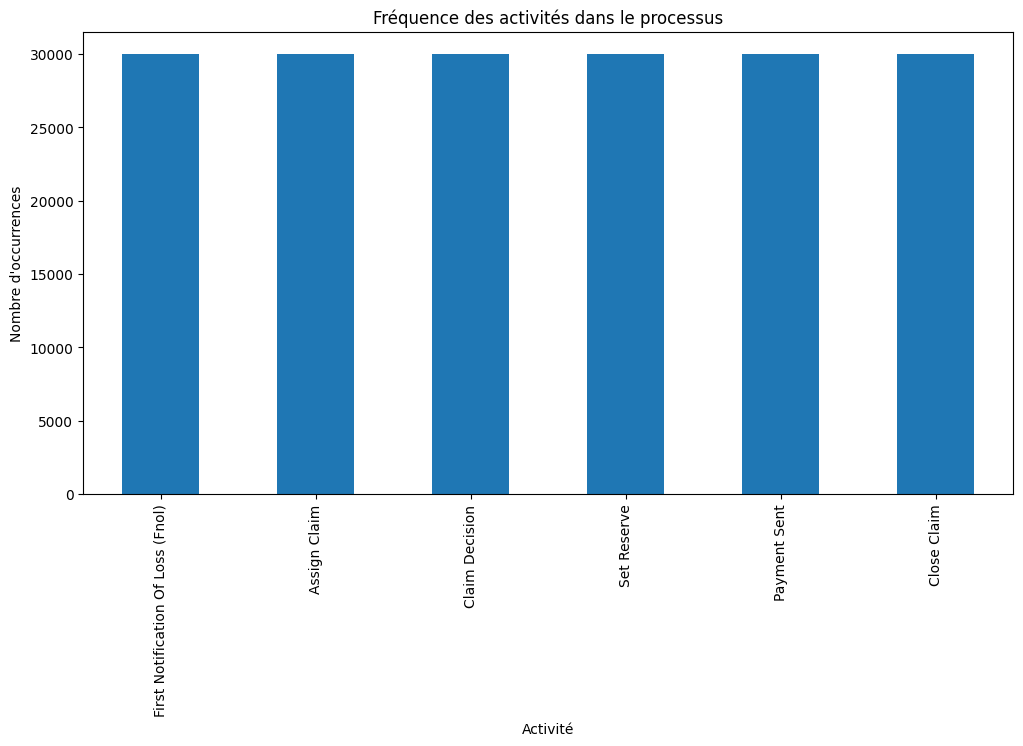

In [20]:
plt.figure(figsize=(12, 6))
activities.plot(kind="bar")
plt.title("Fréquence des activités dans le processus")
plt.xlabel("Activité")
plt.ylabel("Nombre d'occurrences")
plt.show()

In [ ]:
# analyse des transitions entre activités ( Quelle étape suit quelle étape ?)

data["next_activity"] = data.groupby("case_id")["activity_name"].shift(-1)
transitions = data.groupby(["activity_name", "next_activity"]).size().reset_index(name="count")
transitions = transitions.sort_values("count", ascending=False)
transitions.head(10)

,activity_name,next_activity,count
9,First Notification Of Loss (Fnol),Assign Claim,29807
14,Payment Sent,Close Claim,29633
0,Assign Claim,Claim Decision,29621
19,Set Reserve,Payment Sent,29456
6,Claim Decision,Set Reserve,29444
2,Assign Claim,Set Reserve,371
18,Set Reserve,Close Claim,359
5,Claim Decision,Payment Sent,358
10,First Notification Of Loss (Fnol),Claim Decision,192
3,Claim Decision,Assign Claim,190


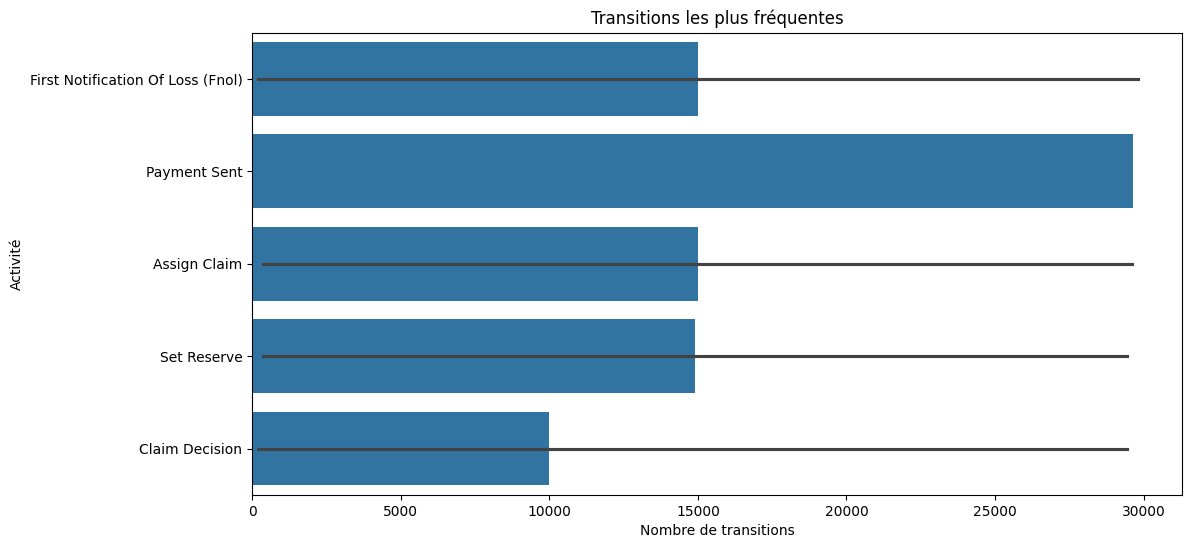

In [23]:
top_transitions = transitions.head(10)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_transitions, x="count", y="activity_name")

plt.title("Transitions les plus fréquentes")
plt.xlabel("Nombre de transitions")
plt.ylabel("Activité")
plt.show()


In [ ]:
# TEMPS ENTRE LES ETAPES on converti en heures pour une meilleure interprétation

data["next_timestamp"] = data.groupby("case_id")["timestamp"].shift(-1)

data["step_duration"] = (
    data["next_timestamp"] - data["timestamp"]
).dt.total_seconds() / 3600

les étapes les plus longues

In [25]:
step_duration_analysis = (
    data.groupby("activity_name")["step_duration"]
    .mean()
    .sort_values(ascending=False)
)

step_duration_analysis

activity_name
First Notification Of Loss (Fnol)    360.155938
Assign Claim                         120.966277
Claim Decision                       120.211736
Set Reserve                          119.947328
Payment Sent                         119.714184
Close Claim                           14.982099
Name: step_duration, dtype: float64

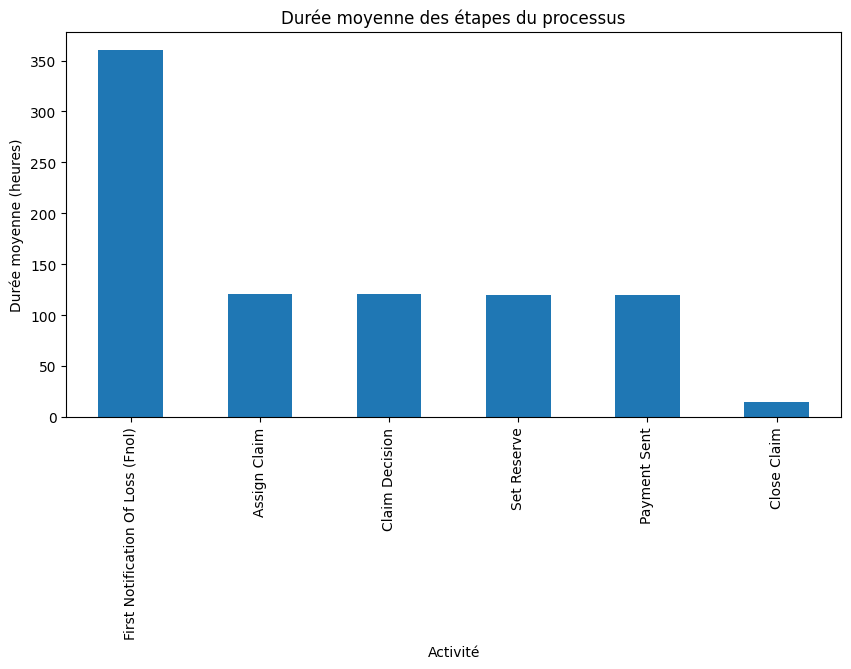

In [26]:
plt.figure(figsize=(10,5))

step_duration_analysis.plot(kind="bar")

plt.title("Durée moyenne des étapes du processus")
plt.xlabel("Activité")
plt.ylabel("Durée moyenne (heures)")

plt.show()

In [27]:
# Ici on regatde si les gros sinistres prennent plus de temps que les petits sinistres
data["claim_category"] = pd.qcut(
    data["claim_amount"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

duration_by_claim = data.groupby("claim_category")["step_duration"].mean()

duration_by_claim

C:\Users\tchib\AppData\Local\Temp\ipykernel_37984\3246217337.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  duration_by_claim = data.groupby("claim_category")["step_duration"].mean()


claim_category
Low          167.852266
Medium       168.472281
High         168.160779
Very High    167.808311
Name: step_duration, dtype: float64

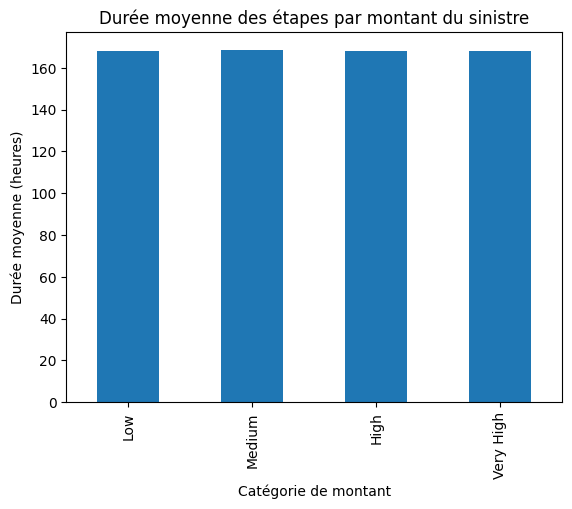

In [28]:
duration_by_claim.plot(kind="bar")

plt.title("Durée moyenne des étapes par montant du sinistre")
plt.xlabel("Catégorie de montant")
plt.ylabel("Durée moyenne (heures)")

plt.show()

In [29]:
# analyse par type d'accident
accident_analysis = (
    data.groupby("type_of_accident")["step_duration"]
    .mean()
    .sort_values(ascending=False)
)

accident_analysis

type_of_accident
Side-impact    168.317114
Rear-end       168.061284
Rollover       167.982163
Head-on        167.928251
Name: step_duration, dtype: float64

In [31]:
# Identifivation des dossiers les plus longs
long_cases = process_durations.sort_values(
    "duration_days",
    ascending=False
).head(10)

long_cases

,min,max,duration_days
case_id,,,
3682174e-c3f8-4259-8116-6bc98f6b5b41,2021-08-15 10:03:52.420652,2021-10-08 13:02:42.686050,54.124193
ae1c5f59-48b6-4282-947e-deaaf6d5b743,2022-03-04 12:44:32.065758,2022-04-27 10:25:19.408672,53.903326
70df7733-a0de-4d20-bcf2-4acdf82cfca5,2021-01-25 10:34:31.737843,2021-03-19 09:47:11.935599,52.967132
2b087b6b-05b4-4c2f-8130-7c3f11b655cc,2022-10-31 20:10:51.470735,2022-12-23 14:45:31.942593,52.774080
caf6187c-00c4-474b-bae8-deee626c04f4,2021-06-21 20:33:19.790684,2021-08-13 07:25:49.571110,52.453122
1c353c4e-7867-43c5-9cc2-99f891729a78,2020-04-21 01:44:07.555268,2020-06-11 22:38:34.034542,51.871140
0773d8ca-238b-4ddd-9f4a-9c68c6a2fce4,2023-02-12 01:41:00.530044,2023-04-04 16:41:40.105151,51.625458
9ed1026e-3382-447e-8d2a-274ec44f9780,2022-04-02 23:25:37.510230,2022-05-23 23:35:09.570080,51.006621
50386088-edf2-4a1d-b457-6f8d4b71b22a,2021-12-12 13:58:35.237790,2022-02-01 09:54:49.728921,50.830723
